In [56]:
import awkward as ak
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt
import mplhep as hep
import vector as vec
import pandas as pd

import matplotlib as mpl

plt.style.use(hep.style.CMS)
%matplotlib inline

In [24]:
filenameS = '/eos/user/a/aperego/tagger/tree_Zjj_10k.root'
fileSignal = uproot.open(filenameS)

filenameB = '/eos/user/a/aperego/tagger/tree_DY_10k.root'
fileBkg = uproot.open(filenameB)

In [25]:
def load_branch_with_highest_cycle(file, branch_name):
    # Get all keys in the file
    all_keys = file.keys()
    # Filter keys that match the specified branch name
    matching_keys = [key for key in all_keys if key.startswith(branch_name)]
    if not matching_keys:
        raise ValueError(f"No branch with name '{branch_name}' found in the file.")
    # Find the key with the highest cycle
    highest_cycle_key = max(matching_keys, key=lambda key: int(key.split(";")[1]))
    # Load the branch with the highest cycle
    branch = file[highest_cycle_key]
    return branch

In [26]:
fS_LHEParticles = load_branch_with_highest_cycle(fileSignal, "LHEParticles")
fS_GenJets = load_branch_with_highest_cycle(fileSignal, "GenJets")
fS_GenParticles = load_branch_with_highest_cycle(fileSignal, "GenParticles")

fB_LHEParticles = load_branch_with_highest_cycle(fileBkg, "LHEParticles")
fB_GenJets = load_branch_with_highest_cycle(fileBkg, "GenJets")
fB_GenParticles = load_branch_with_highest_cycle(fileBkg, "GenParticles")

In [27]:
print(fS_LHEParticles.keys())
print(fS_GenJets.keys())
print(fS_GenParticles.keys())

['LHEPart_pt', 'LHEPart_eta', 'LHEPart_phi', 'LHEPart_mass', 'LHEPart_pdgId', 'LHEPart_status']
['GenJet_pt', 'GenJet_eta', 'GenJet_phi', 'GenJet_mass', 'GenJet_nConstituents', 'GenJet_constituents']
['nGenPart', 'GenPart_pt', 'GenPart_eta', 'GenPart_phi', 'GenPart_mass', 'GenPart_pdgId']


In [28]:
LHEParticles_s = fS_LHEParticles.arrays(fS_LHEParticles.keys())
GenJets_s = fS_GenJets.arrays(fS_GenJets.keys())
GenParticles_s = fS_GenParticles.arrays(fS_GenParticles.keys())

LHEParticles_b = fB_LHEParticles.arrays(fB_LHEParticles.keys())
GenJets_b = fB_GenJets.arrays(fB_GenJets.keys())
GenParticles_b = fB_GenParticles.arrays(fB_GenParticles.keys())

In [29]:
def getJetConstituents(i, nConst, allConst):
    return allConst[sum(nConst[:i]):sum(nConst[:i+1])]

In [30]:
def getManyJetsConstituents(i, j, nConst, allConst):
    return allConst[sum(nConst[:i]):sum(nConst[:j+1])]

In [31]:
getManyJetsConstituents(0,3, GenJets_b.GenJet_nConstituents[0], GenJets_b.GenJet_constituents[0])

<Array [692, 378, 689, 376, ... 261, 33, 140] type='125 * int32'>

## features

In [32]:
def pull_angle(jpa, jpb):
    t = jpa+jpb
    v = vec.obj(rho=1, eta=jpa.eta-jpb.eta, phi=jpa.phi-jpb.eta)
    tp = t@v
    
    return tp
def jet_colour_ring(jeta, jetb, gluon):
    dak = (jeta.eta-gluon.eta)**2 + (jeta.phi-gluon.phi)**2
    dbk = (jetb.eta-gluon.eta)**2 + (jetb.phi-gluon.phi)**2
    dab = (jeta.eta-jetb.eta)**2  + (jeta.phi-jetb.phi)**2
    
    return (dak+dbk)/dab

def event_jet_pull(GenJets, GenParticles, ev):
    genjets_pt = GenJets.GenJet_pt[ev]
    nConstituents = GenJets.GenJet_nConstituents[ev]
    constituents = GenJets.GenJet_constituents[ev]
    genParts_pt = GenParticles.GenPart_pt[ev]
    genParts_eta = GenParticles.GenPart_eta[ev]
    genParts_phi = GenParticles.GenPart_phi[ev]
    genJets_eta = GenJets.GenJet_eta[ev]
    genJets_phi = GenJets.GenJet_phi[ev]
        
    NJETS = len(GenJets.GenJet_pt[ev])
    genjets_pull = []
    
    pulls_m = []
    pulls_eta = []
    pulls_phi = []
    
    
    for i in range(NJETS):
        pull_m = 0
        pull_eta = 0
        pull_phi = 0
        
        genPartsInJetIndices = getJetConstituents(i, nConstituents, constituents)
        
        cs_pt  = genParts_pt[genPartsInJetIndices]
        cs_eta = genParts_eta[genPartsInJetIndices]
        cs_phi = genParts_phi[genPartsInJetIndices]
        
        jet_pt  = GenJets.GenJet_pt[ev][i]
        jet_eta = GenJets.GenJet_eta[ev][i]
        jet_phi = GenJets.GenJet_phi[ev][i]
        
        for c_pt, c_eta, c_phi in zip(cs_pt, cs_eta, cs_phi):
            pti = c_pt
            ri2 = (c_eta-jet_eta)**2+(c_phi-jet_phi)**2
            m = pti*ri2
            pull_m += m
            pull_eta += (c_eta-jet_eta)*m
            pull_phi += (c_phi-jet_phi)*m

        
        pull_m /= jet_pt
        pull_eta /= jet_pt
        pull_phi /= jet_pt
        
        pulls_m.append(pull_m)
        pulls_eta.append(pull_eta)
        pulls_phi.append(pull_phi)
        
        
    
    return pulls_m, pulls_eta, pulls_phi


In [33]:
from numba import njit
import awkward.numba

@njit
def getJetConstituents_numba(i, nConst, allConst):
    start = 0
    for j in range(i):
        start += nConst[j]
    end = start + nConst[i]
    return allConst[start:end]

@njit
def wrapInPhi_numba(phi):
    x = (phi + np.pi) % (2 * np.pi) - np.pi
    return x

@njit
def event_jet_pull_numba(GenJets, GenParticles, ev):
    genjets_pt = GenJets.GenJet_pt[ev]
    nConstituents = GenJets.GenJet_nConstituents[ev]
    constituents = GenJets.GenJet_constituents[ev]
    genParts_pt = GenParticles.GenPart_pt[ev]
    genParts_eta = GenParticles.GenPart_eta[ev]
    genParts_phi = GenParticles.GenPart_phi[ev]
    genJets_eta = GenJets.GenJet_eta[ev]
    genJets_phi = GenJets.GenJet_phi[ev]
      
    pulls_m = []
    pulls_eta = []
    pulls_phi = []
    
    for i in range(len(GenJets.GenJet_pt[ev])):
        pull_m = 0
        pull_eta = 0
        pull_phi = 0
        
        genPartsInJetIndices = getJetConstituents_numba(i, nConstituents, constituents)

        cs_pt =[]
        cs_eta =[]
        cs_phi =[]
                
        for gpidx in genPartsInJetIndices:
            cs_pt.append(genParts_pt[gpidx])
            cs_eta.append(genParts_eta[gpidx])
            cs_phi.append(genParts_phi[gpidx])
        
        # print ('cs_pt', cs_pt)
        
        jet_pt  = GenJets.GenJet_pt[ev][i]
        jet_eta = GenJets.GenJet_eta[ev][i]
        jet_phi = GenJets.GenJet_phi[ev][i]
        
        jet_phi = wrapInPhi_numba(jet_phi)        
        
        for c_pt, c_eta, c_phi in zip(cs_pt, cs_eta, cs_phi):
            c_phi = wrapInPhi_numba(c_phi)
            pti = c_pt
            ri2 = (c_eta-jet_eta)**2+wrapInPhi_numba(c_phi-jet_phi)**2
            m = pti*ri2
            pull_m += m
            pull_eta += (c_eta-jet_eta)*m
            pull_phi += wrapInPhi_numba(c_phi-jet_phi)*m

        
        pull_m /= jet_pt
        pull_eta /= jet_pt
        pull_phi /= jet_pt
        
        pulls_m.append(pull_m)
        pulls_eta.append(pull_eta)
        pulls_phi.append(pull_phi)
        
        
    
    return pulls_m, pulls_eta, pulls_phi

In [34]:
jets_pull_s = [[],[],[]]
jets_pull_b = [[],[],[]]
for i in range(len(GenJets_s)):
    pulls_signal = event_jet_pull_numba(GenJets_s, GenParticles_s, i)
    jets_pull_s[0].append(pulls_signal[0])    
    jets_pull_s[1].append(pulls_signal[1])    
    jets_pull_s[2].append(pulls_signal[2])  
    pulls_bkg = event_jet_pull_numba(GenJets_b, GenParticles_b, i)
    jets_pull_b[0].append(pulls_bkg[0])
    jets_pull_b[1].append(pulls_bkg[1])    
    jets_pull_b[2].append(pulls_bkg[2])    

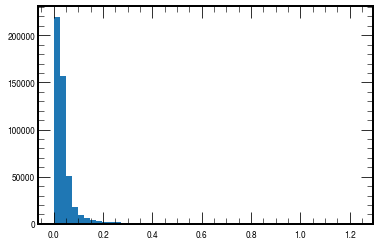

In [35]:
plt.hist([p for pulls in jets_pull_s[0] for p in pulls], bins=50)
plt.show()

In [38]:
def wrapInPhi(phi):
    """Map angle values to the range [-pi, pi]."""
    return (phi + np.pi) % (2 * np.pi) - np.pi

## mjj, etajj, pt third jet

In [39]:
def getJetsDataFrame(GenJets):
    genJets_pt = GenJets.GenJet_pt
    genJets_eta = GenJets.GenJet_eta
    genJets_phi = wrapInPhi(GenJets.GenJet_phi)
    events_id = np.arange(len(genJets_pt))
#     if not isSignal:
#         events_id += 10000
    pt1 = GenJets.GenJet_pt[:,0]
    pt2 = GenJets.GenJet_pt[:,1]
    eta1 = GenJets.GenJet_eta[:,0]
    eta2 = GenJets.GenJet_eta[:,1]
    eta3 = GenJets.GenJet_eta[:,2]
    phi1 = GenJets.GenJet_phi[:,0]
    phi2 = GenJets.GenJet_phi[:,1]
    
    mjj = np.sqrt(2*pt1*pt2*(np.cosh(eta1-eta2)-np.cos(phi1-phi2)))
    etajj = eta1-eta2
    pt3 = GenJets.GenJet_pt[:,2]
    zepp = ((eta3 - (eta1+eta2)/2) / abs(eta1-eta2))
    
#     # Flatten the arrays (along axis=0, combining the particles from all events)
#     flat_pt = ak.flatten(genJets_pt)
#     flat_eta = ak.flatten(genJets_eta)
#     flat_phi = ak.flatten(genJets_phi)
#     flat_mass = ak.flatten(genJets_mass)
#     jetpull = [p for pulls in jets_pull[0] for p in pulls]
#     flat_nConstituents = ak.flatten(nConstituents)
#     labels = ak.ones_like(flat_pt) if isSignal else ak.zeros_like(flat_pt)

    # Create a pandas DataFrame
    df = pd.DataFrame({
        'ev': events_id,
        'mjj': mjj,
        'etajj': abs(etajj),
        'pt3': pt3,
        'zepp': zepp
    })
    df['ev'] = df['ev'].astype(int)
# # row: leptoni @ LHE
# # filtro eventi con getti con pt>30?
# # Group by 'ev' and filter groups that have at least two rows with pt > 30
# #filtered_df = df.groupby('ev').filter(lambda x: (x['pt'] > 30).sum() >= 2)
# # nel get si fa df[df["evt"==idx]]


#     if verbose:
#         print(df)
    
    return df

In [40]:
dfS = getJetsDataFrame(GenJets_s)
dfB = getJetsDataFrame(GenJets_b)

In [41]:
dfB

,ev,mjj,etajj,pt3,zepp
0,0,247.971802,0.053757,104.676147,9.036774
1,1,216.387207,1.460565,62.562599,-0.545576
2,2,58.720230,0.761370,8.159304,1.440366
3,3,278.703613,0.486169,61.961727,-2.034255
4,4,467.656982,2.416612,34.179050,0.321960
...,...,...,...,...,...
9995,9995,415.302612,0.809568,56.958462,4.873824
9996,9996,248.073425,1.559175,69.776245,1.747274
9997,9997,62.292404,0.011036,35.349476,-93.047241
9998,9998,83.014160,0.270200,18.710953,0.631132


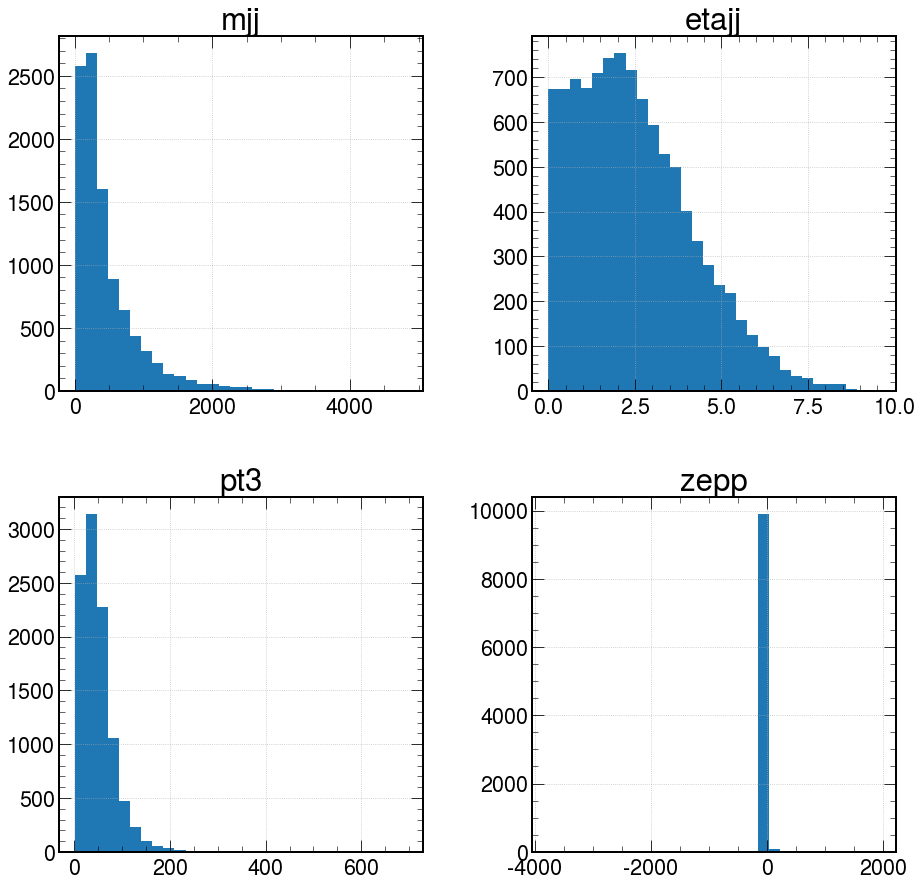

In [45]:
plt.style.use(hep.style.CMS)
axs = dfS[["mjj","etajj","pt3", "zepp"]].hist(figsize=(15,15), bins=30)
# axs = dfS.plot.area(figsize=(8,20), subplots=True, stacked=False)
plt.show()

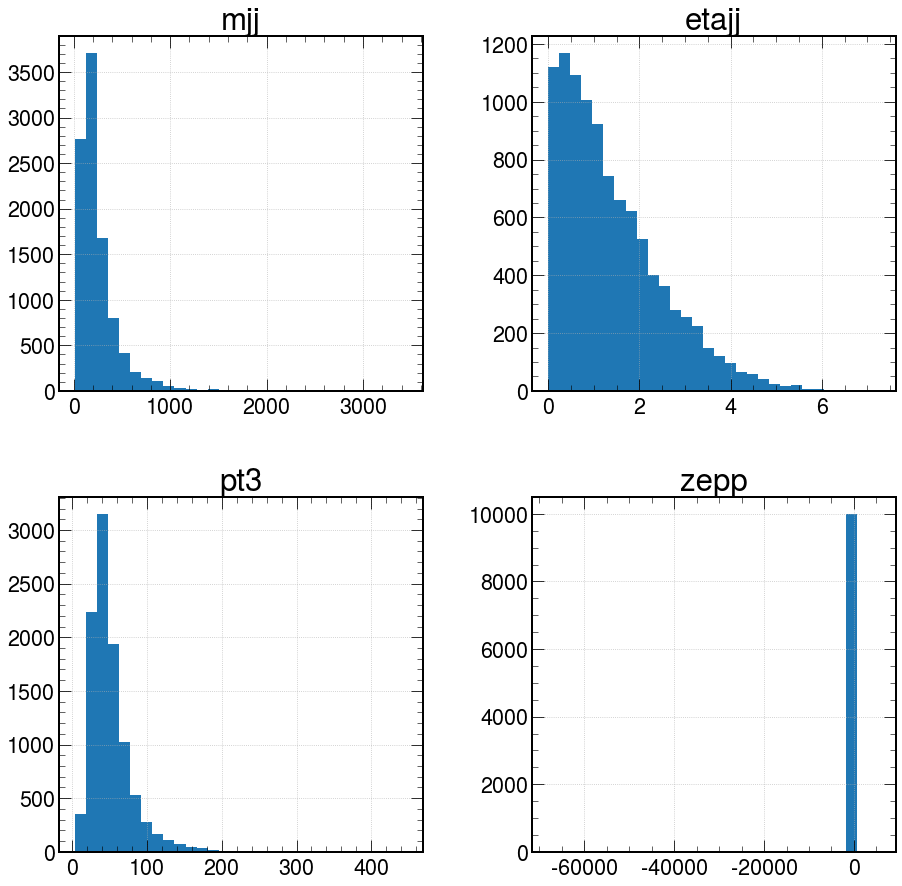

In [44]:
axs = dfB[["mjj","etajj","pt3","zepp"]].hist(figsize=(15,15), bins=30)
# axs = dfS.plot.area(figsize=(8,20), subplots=True, stacked=False)
plt.show()

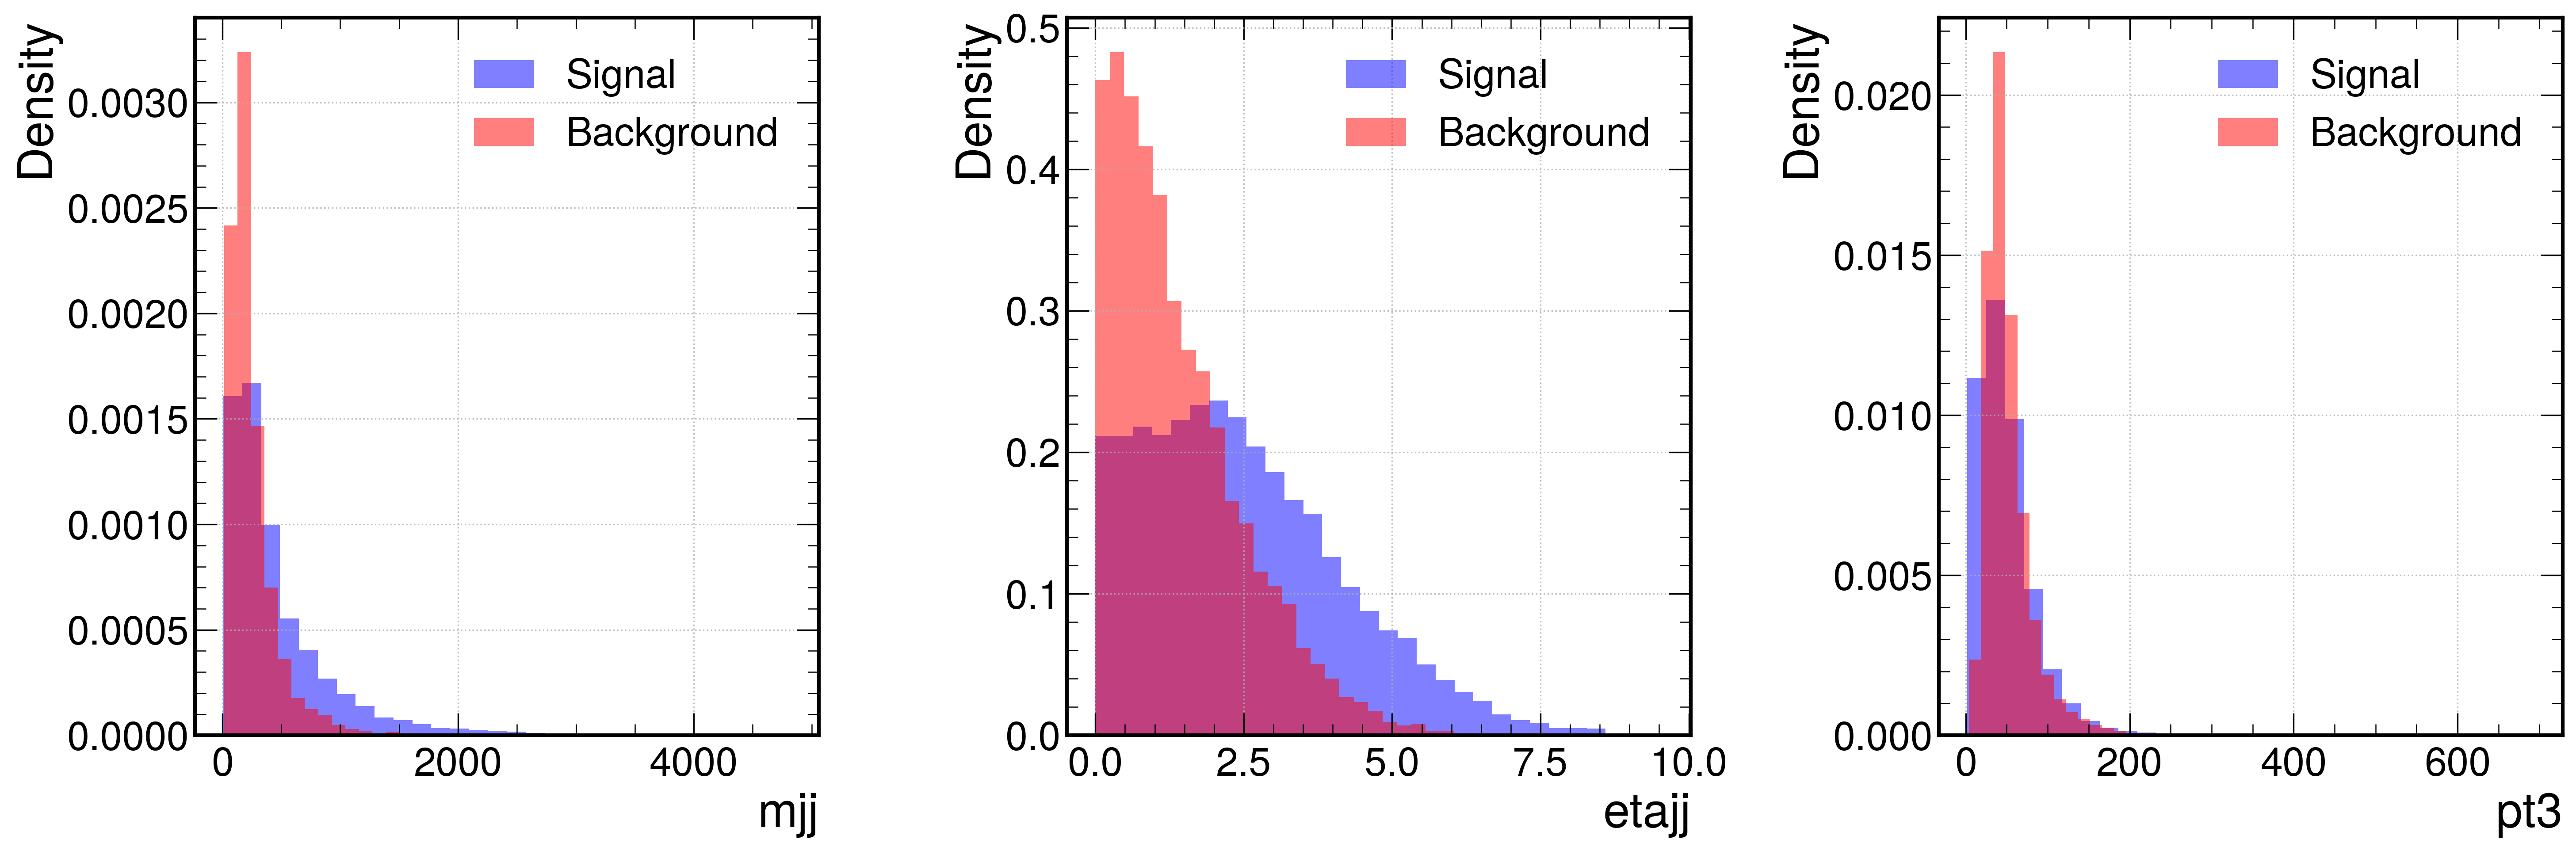

In [52]:
# Set CMS style for plots
plt.style.use(hep.style.CMS)

# Define features to plot
features = ["mjj", "etajj", "pt3"]

# Create a figure with one subplot per feature
fig, axs = plt.subplots(1, len(features), figsize=(20, 7), dpi=300)

# Plot each feature
for i, feat in enumerate(features):
    axs[i].hist(dfS[feat], bins=30, color='blue', alpha=0.5, label='Signal', density=True)
    axs[i].hist(dfB[feat], bins=30, color='red', alpha=0.5, label='Background', density=True)

    # Set labels and title for each subplot
    axs[i].set_xlabel(feat)
    axs[i].set_ylabel('Density')
    axs[i].legend()
    axs[i].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

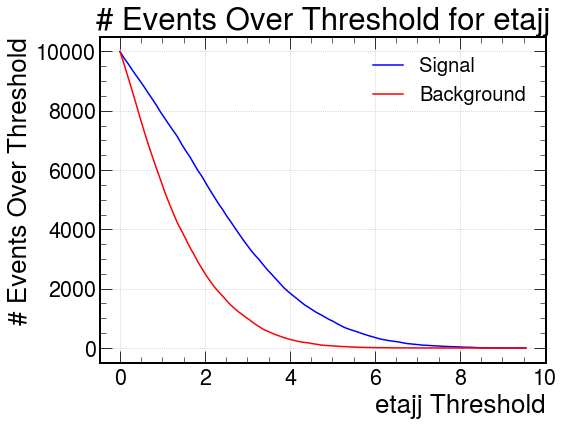

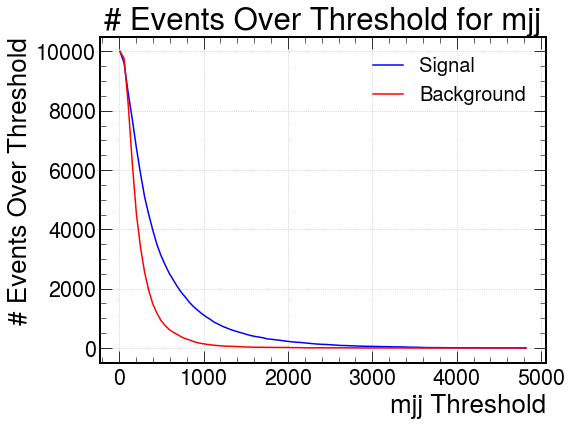

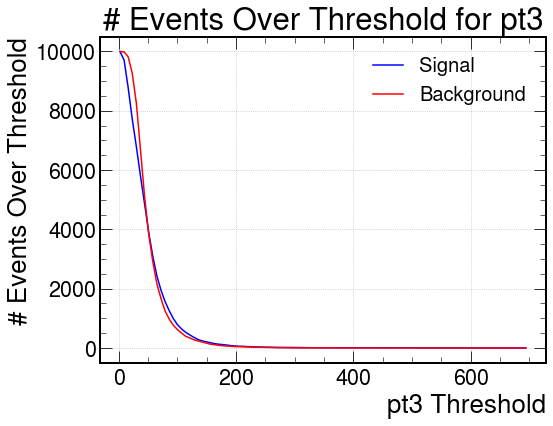

In [54]:
# Assuming signal_df and bkg_df are your DataFrames
def plot_events_over_threshold(signal_df, bkg_df, features):
    for feat in features:
        # Get the maximum value of the feature across both dataframes
        min_value = min(signal_df[feat].min(), bkg_df[feat].min())
        max_value = max(signal_df[feat].max(), bkg_df[feat].max())
        
        if feat == "zepp":
            min_value = -25
            max_value = 25
        
        # Create threshold values from 0 to max_value
        thresholds = np.linspace(min_value, max_value, 100)
        
        # Calculate the number of events over threshold for both signal and background
        signal_counts = [signal_df[signal_df[feat] > thresh].shape[0] for thresh in thresholds]
        bkg_counts = [bkg_df[bkg_df[feat] > thresh].shape[0] for thresh in thresholds]
        
        # Plotting
        plt.figure(figsize=(8, 6))
        plt.plot(thresholds, signal_counts, label='Signal', color='blue')
        plt.plot(thresholds, bkg_counts, label='Background', color='red')
        plt.xlabel(f'{feat} Threshold')
        plt.ylabel('# Events Over Threshold')
        plt.title(f'# Events Over Threshold for {feat}')
        plt.legend(fontsize=20)
        plt.grid()
        plt.show()

# List of feature columns
features = ['etajj', 'mjj', 'pt3']

# Assuming signal_df and bkg_df are defined, call the function
plot_events_over_threshold(dfS, dfB, features)

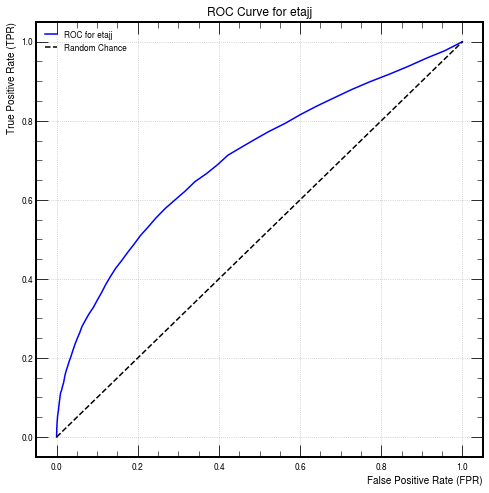

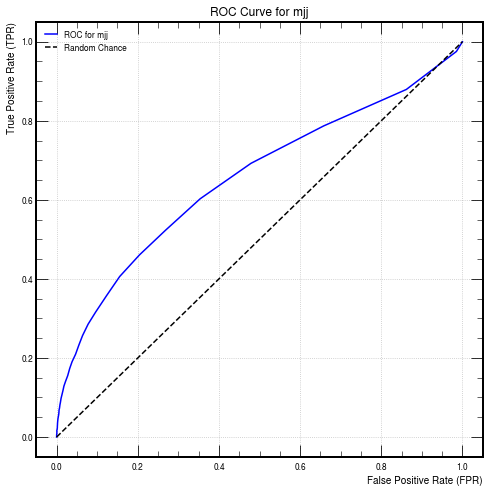

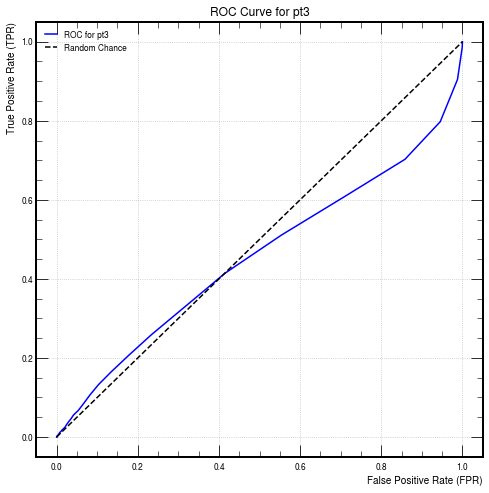

In [101]:
# Assuming signal_df and bkg_df are your DataFrames
def plot_roc_curve(signal_df, bkg_df, features):
    for feat in features:
        # Get the maximum value of the feature across both dataframes
        max_value = max(signal_df[feat].max(), bkg_df[feat].max())
        
#         if feat == "pt3":
#             min_value = 0
#             max_value = 200
            
#         if feat == "zepp":
#             min_value = -10
#             max_value = 10
            
        # Create threshold values from 0 to max_value
        thresholds = np.linspace(0, max_value, 100)
        
        # Calculate TPR and FPR for each threshold
        tpr = []
        fpr = []
        
        total_signal = len(signal_df)
        total_background = len(bkg_df)
        
        for thresh in thresholds:
            # True Positive Rate: fraction of signal events above threshold
            tp = signal_df[signal_df[feat] > thresh].shape[0]
            tpr.append(tp / total_signal if total_signal > 0 else 0)
            
            # False Positive Rate: fraction of background events above threshold
            fp = bkg_df[bkg_df[feat] > thresh].shape[0]
            fpr.append(fp / total_background if total_background > 0 else 0)
        
        # Plotting ROC Curve
        plt.figure(figsize=(8, 8))
        plt.plot(fpr, tpr, label=f'ROC for {feat}', color='blue')
        plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR)')
        plt.title(f'ROC Curve for {feat}')
        plt.legend()
        plt.grid()
        plt.show()

# List of feature columns
features = ['etajj', 'mjj', 'pt3']

# Assuming signal_df and bkg_df are defined, call the function
plot_roc_curve(dfS, dfB, features)


In [107]:
# Function to find optimal thresholds that maximize signal and minimize background
def find_optimal_thresholds(signal_df, bkg_df, features):
    optimal_thresholds = {}

    for feat in features:
        # Get the maximum value of the feature across both dataframes
        max_value = max(signal_df[feat].max(), bkg_df[feat].max())
        
        # Create threshold values from 0 to max_value
        thresholds = np.linspace(0, max_value, 100)
        
        best_threshold = None
        best_significance = 0
        
        total_signal = len(signal_df)
        total_background = len(bkg_df)
        
        for thresh in thresholds:
            # Calculate TPR (signal passing fraction) and FPR (background passing fraction)
            tp = signal_df[signal_df[feat] > thresh].shape[0]
            fp = bkg_df[bkg_df[feat] > thresh].shape[0]
            
            tpr = tp / total_signal if total_signal > 0 else 0
            fpr = fp / total_background if total_background > 0 else 0
            
            # Calculate signal significance
            significance = tpr / np.sqrt(fpr) if fpr > 0 else 0
            
            # Check if this threshold gives a higher significance
            if significance > best_significance:
                best_significance = significance
                best_threshold = thresh
        
        # Store the best threshold for this feature
        optimal_thresholds[feat] = best_threshold
        print(f"Optimal threshold for {feat}: {best_threshold}, with significance: {best_significance:.4f}")

    return optimal_thresholds

# List of feature columns
features = ['etajj', 'mjj', 'pt3']

# Assuming signal_df and bkg_df are defined, call the function
optimal_thresholds = find_optimal_thresholds(dfS, dfB, features)


Optimal threshold for etajj: 6.562274586070667, with significance: 1.1720
Optimal threshold for mjj: 389.4181660353535, with significance: 1.0299
Optimal threshold for pt3: 0.0, with significance: 1.0000


In [118]:
import numpy as np
import pandas as pd
from itertools import product

# Function to find optimal combination of thresholds that maximize signal significance
def find_optimal_combination_thresholds(signal_df, bkg_df, features, num_thresholds=50):
    optimal_thresholds = {}
    best_significance = 0
    best_combination = {}

    # Define threshold ranges for each feature
    threshold_ranges = {
        feat: np.linspace(0, max(signal_df[feat].max(), bkg_df[feat].max()), num_thresholds)
        for feat in features
    }

    # Evaluate all combinations of thresholds
    for threshold_combo in product(*(threshold_ranges[feat] for feat in features)):
        # Create a dictionary of the current thresholds for each feature
        thresholds = {feat: threshold_combo[i] for i, feat in enumerate(features)}

        # Apply the combined thresholds to both signal and background data
        signal_pass = signal_df[
            (signal_df[features[0]] > thresholds[features[0]]) &
            (signal_df[features[1]] > thresholds[features[1]]) &
            (signal_df[features[2]] > thresholds[features[2]])
        ]
        bkg_pass = bkg_df[
            (bkg_df[features[0]] > thresholds[features[0]]) &
            (bkg_df[features[1]] > thresholds[features[1]]) &
            (bkg_df[features[2]] > thresholds[features[2]])
        ]

        # Number of events that pass the threshold
        num_signal_pass = len(signal_pass)
        num_bkg_pass = len(bkg_pass)

        # Calculate significance as Signal / sqrt(Background), and handle zero background
        significance = num_signal_pass / np.sqrt(num_bkg_pass) if num_bkg_pass > 0 else 0

        # Update optimal thresholds if this combination is better
        if significance > best_significance:
            best_significance = significance
            best_combination = thresholds

    # Store and print the best combination of thresholds and its significance
    print("Optimal combination of thresholds:")
    for feat, threshold in best_combination.items():
        print(f"{feat}: {threshold}")
    print(f"Maximized significance: {best_significance:.4f}")

    return best_combination

# List of feature columns
features = ['etajj', 'mjj', 'pt3']

# Assuming signal_df and bkg_df are defined, call the function
optimal_thresholds = find_optimal_combination_thresholds(dfS, dfB, features)

Optimal combination of thresholds:
etajj: 2.144753008472676
mjj: 0.0
pt3: 0.0
Maximized significance: 112.1489


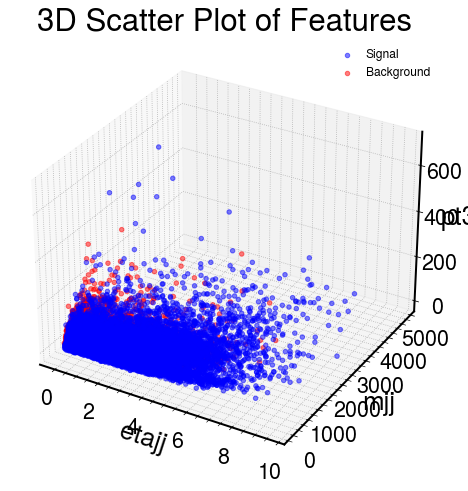

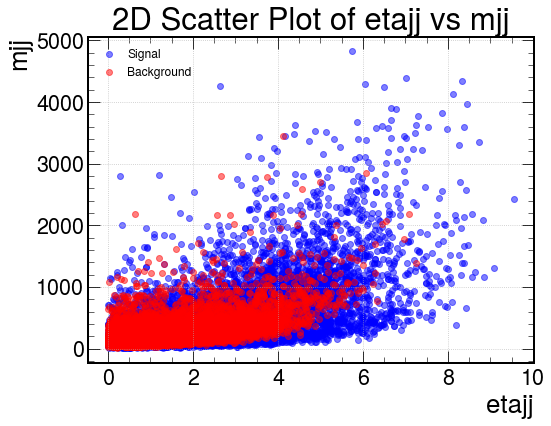

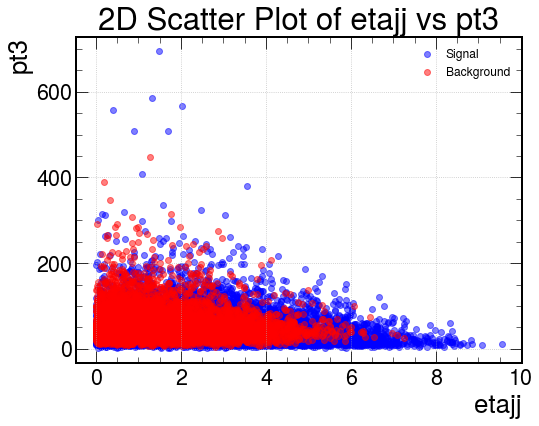

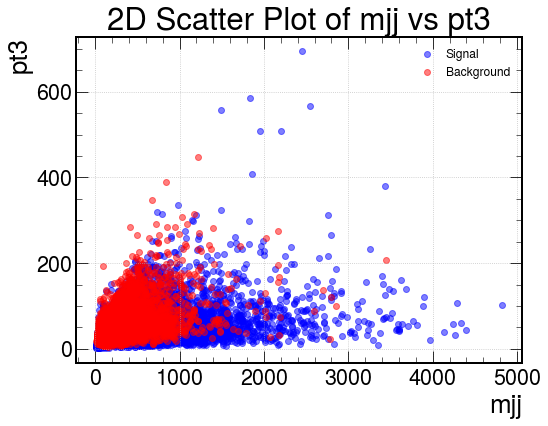

In [58]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Function to plot 3D scatter of all features
def plot_3d_features(signal_df, bkg_df, features):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 3D Scatter plot for signal
    ax.scatter(signal_df[features[0]], signal_df[features[1]], signal_df[features[2]], 
               color='blue', label='Signal', alpha=0.5)
    
    # 3D Scatter plot for background
    ax.scatter(bkg_df[features[0]], bkg_df[features[1]], bkg_df[features[2]], 
               color='red', label='Background', alpha=0.5)
    
    # Setting labels
    ax.set_xlabel(features[0])
    ax.set_ylabel(features[1])
    ax.set_zlabel(features[2])
    ax.set_title('3D Scatter Plot of Features')
    ax.legend(fontsize=12)
    plt.show()

# Function to plot 2D scatter plots of pairs of features
def plot_2d_feature_pairs(signal_df, bkg_df, features):
    feature_pairs = [(features[0], features[1]), (features[0], features[2]), (features[1], features[2])]
    
    for feat_x, feat_y in feature_pairs:
        plt.figure(figsize=(8, 6))
        
        # 2D scatter for signal
        plt.scatter(signal_df[feat_x], signal_df[feat_y], color='blue', label='Signal', alpha=0.5)
        
        # 2D scatter for background
        plt.scatter(bkg_df[feat_x], bkg_df[feat_y], color='red', label='Background', alpha=0.5)
        
        # Setting labels and title
        plt.xlabel(feat_x)
        plt.ylabel(feat_y)
        plt.title(f'2D Scatter Plot of {feat_x} vs {feat_y}')
        plt.legend(fontsize=12)
        plt.grid()
        plt.show()

# List of feature columns
features = ['etajj', 'mjj', 'pt3']

plt.style.use(hep.style.CMS)
# Assuming signal_df and bkg_df are defined, call the functions
plot_3d_features(dfS, dfB, features)
plot_2d_feature_pairs(dfS, dfB, features)

In [113]:
filtered_dfS = dfS[(dfS['mjj'] > 500) & (dfS['etajj'] > 3) & (dfS['pt3'] < 100)]
filtered_dfB = dfB[(dfB['mjj'] > 500) & (dfB['etajj'] > 3) & (dfB['pt3'] < 100)]

In [55]:
filtered_dfS

NameError: name 'filtered_dfS' is not defined

In [115]:
filtered_dfB

,ev,mjj,etajj,pt3,zepp
11,11,559.211975,3.022594,36.462715,-0.955415
20,20,620.135071,3.105056,86.740112,0.058476
55,55,2182.200195,7.093314,32.766872,-0.046068
135,135,763.264099,3.781650,41.448467,-0.624351
139,139,833.519409,4.881204,46.043873,-0.424715
...,...,...,...,...,...
9852,9852,560.155823,3.580739,47.070831,-0.062601
9856,9856,730.046936,4.927097,36.560638,0.569718
9923,9923,576.844971,4.270154,62.563393,-0.524797
9924,9924,777.891418,3.575341,93.395935,-0.464208


In [117]:
1969/np.sqrt(407)

97.59970646832244